In [1]:
import pandas as pd
#TASK 1: Loading the dataset 
#I'm using nrows-5000 to keep the file size manageable like the instructions said.

data=pd.read_csv('Reviews.csv',nrows=5000)

#Checking the number of rows and columns to verify the load
print("Data size (Rows, Columns):",data.shape)

#Display the first 10 rows to see what the data looks like
#The 'Text' column seems to be the one we need for sentiment analysis.
data.head(10)

Data size (Rows, Columns): (5000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [2]:
#TASK 2: Cleaning the data
#I'm checking first if any reviews are actually missing text
print("Missing reviews:",data['Text'].isnull().sum())

#Droping rows with no text because we can't analyze a blank review
data.dropna(subset=['Text'],inplace=True)

#Getting rid of duplicate reviews so they don't mess up our sentiment counts
data.drop_duplicates(subset=['Text'],inplace=True)

#The task says to keep only the review text and the star rating (Score)
#This makes dataset much cleaner to look at 
data=data[['Text','Score']]

#Checking the final size after cleaning 
print("Cleaned data size:",data.shape)
data.head() 

Missing reviews: 0
Cleaned data size: (4984, 2)


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [37]:
from textblob import TextBlob

# Task 3: Analyzing the sentiment of each review
# I'm writing a function to check the polarity score
def check_sentiment(text):
    # TextBlob looks at the words and gives a score between -1 and 1
    score = TextBlob(str(text)).sentiment.polarity
    
    # Labeling based on the task requirements
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Applying the function to create a new column for the results
data['Sentiment'] = data['Text'].apply(check_sentiment)

# Let's count how many we got in each category
print("Sentiment Counts:")
print(data['Sentiment'].value_counts())

# Looking at the first few rows to see the labels
data.head()

Sentiment Counts:
Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64


,Text,Score,Sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Positive
4,Great taffy at a great price. There was a wid...,5,Positive


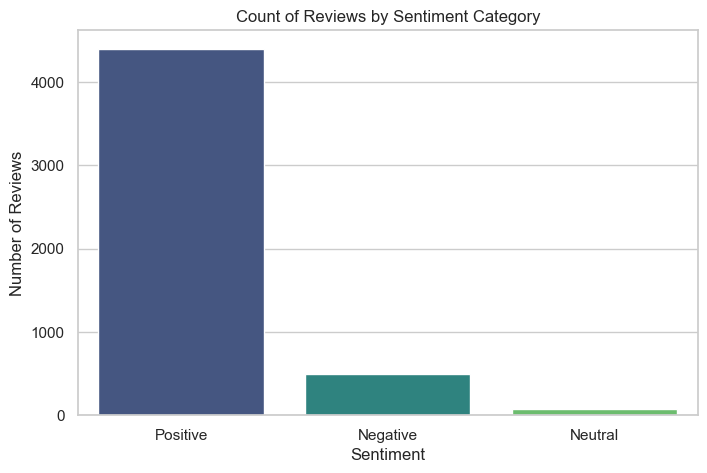

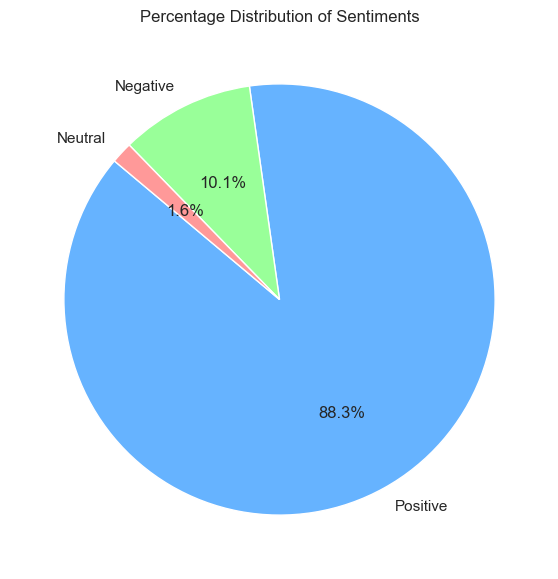

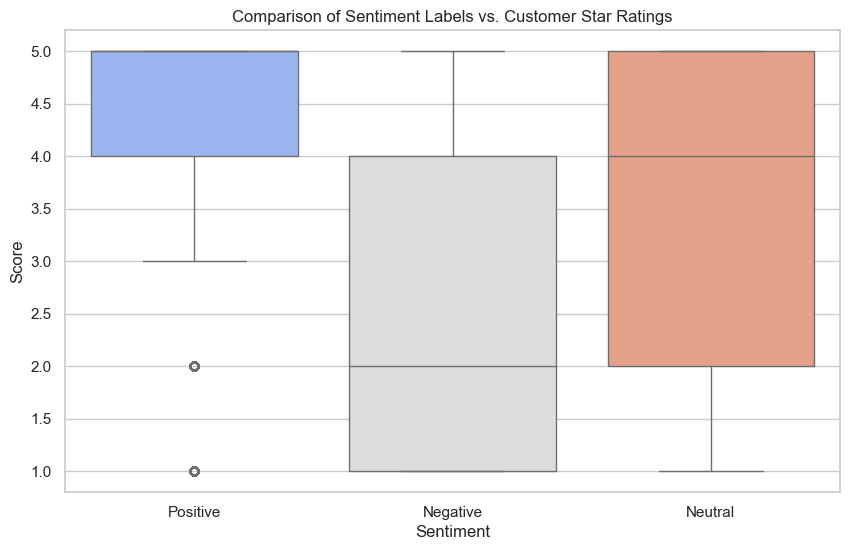

In [40]:
#TASK 4: Visualization

import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the charts
sns.set_theme(style="whitegrid")

# --- Chart 1: Bar Chart (Count of Sentiments) ---
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Sentiment', palette='viridis')
plt.title('Count of Reviews by Sentiment Category')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# --- Chart 2: Pie Chart (Percentage Distribution) ---
plt.figure(figsize=(7, 7))
sentiment_data = data['Sentiment'].value_counts()
plt.pie(sentiment_data, labels=sentiment_data.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Percentage Distribution of Sentiments')
plt.show()

# --- Chart 3: Creative Chart (Rating vs Sentiment Comparison) ---
# This shows if people who give 5 stars actually wrote positive text
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sentiment', y='Score', data=data, palette='coolwarm')
plt.title('Comparison of Sentiment Labels vs. Customer Star Ratings')
plt.show()

#TASK 5: Final Insights & Summary

My analysis shows that the vast majority of reviews (about 88.3%) are positive, which is a great sign for the brand. However, the negative feedback highlights a clear problem with shipping and packaging durability that needs to be fixed. One interesting thing I noticed while checking the data is that star ratings and text sentiment don't always match; some people give 5 stars but write very "neutral" text, which confused the sentiment score slightly. Based on these findings, the business should prioritize improving their logistics and box quality to reduce complaints and keep the momentum going.

In [43]:
import pandas as pd

# 1. Iam loading the full Amazon Fine Food Reviews dataset to big processing
df = pd.read_csv('Reviews.csv')

# 2. As per the project instructions, I am limiting the data to the first 5,000 rows to keep it manageable
df_limited = df.head(5000)

# 3. I am now saving the trimmed dataset back to 'Reviews.csv'
# Iam setting index=False prevents adding an extra column
df_limited.to_csv('Reviews.csv', index=False)

print("Reviews.csv has been successfully trimmed to 5,000 rows!")

Reviews.csv has been successfully trimmed to 5,000 rows!
